## Activity Comparison

This notebook contains the core analysis comparing gaze behavior across our shortlisted
activities. We use the preprocessed sessions from `00_data_prep.ipynb` and apply the
two-participant policy defined here before any analysis runs.

**Two-participant policy:** Activities where two participants were recorded together are
handled differently depending on the nature of the activity. Solo/social splits
(Cooking, Housekeeping) are treated as separate sub-activities to test whether social
context changes gaze behavior. Activities that are inherently social (Having a meal, Game night, Fresh air) merge both session types into one bucket.
Activities where participant roles differ (Where is X, Welcome to my place, In the office)
exclude two-participant sessions entirely.

**What this notebook covers:**

1. **Pitch and yaw centroids** — mean vertical and horizontal gaze per activity with 95% CI,
confirming that pitch encodes activity while yaw remains invariant. Each centroid is the
mean of per-session means, so every participant weighs equally regardless of session length.

2. **2D centroid scatter** — yaw vs. pitch on equal axes, making the invariance of horizontal
gaze and the spread of vertical gaze immediately visible.

3. **Population gaze density maps** — per-activity heatmaps on shared 80×80 bins and a shared
colorscale clipped to the 99th percentile (to prevent hotspot outliers from washing out the
rest of the distribution), sorted from most heads-down to least. Each map averages per-session
normalized histograms so every participant weighs equally regardless of session length.

4. **Between-participant spread** — SD of mean pitch and yaw per activity, showing how
consistently participants look in the same direction within each activity. Differences across
activities are modest; this finding is reported in the paper in words rather than as a figure.

5. **Pairwise Cohen's d** — effect sizes for all activity pairs, quantifying how
separable activities are by vertical gaze alone.


In [1]:
from pathlib import Path

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from itertools import combinations

import nymeria_gaze_tools as ngt

pio.renderers.default = "png"

DATA_ROOT    = Path("../data/processed")
SESSIONS_DIR = DATA_ROOT / "sessions_preprocessed"
FIGURES_DIR  = Path("figures/activity_comparison")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "yellow": "#F0E442",
}

SHORTLISTED_ACTIVITIES = [
    "S1-Relax_at_home",
    "S2-Where_is_X",
    "S3-Welcome_to_my_place",
    "S7-Cooking",
    "S8-Having_a_meal",
    "S10-Housekeeping",
    "S11-Laundary",
    "S12-Game_night",
    "S13-Charades",
    "S17-In_the_office",
    "S19-Fresh_air",
]

TWO_PARTICIPANT_POLICY = {
    "S7-Cooking":       "split",  # compare solo vs. social cooking
    "S10-Housekeeping": "split",  # compare solo vs. social housekeeping
    "S8-Having_a_meal": "merge",  # the activity is social so the 1-partitipant and 2-partitipant versions are the same.
    "S12-Game_night":   "merge",  # the activity is social so the 1-partitipant and 2-partitipant versions are the same.
    "S19-Fresh_air":    "merge",  # the activity is social so the 1-partitipant and 2-partitipant versions are the same.
    # S2, S3, S17: exclude — roles differ between participants in some sessions
    # S1, S11, S13: single-participant only
}

print("Setup complete.")


Setup complete.


In [2]:
catalog = pd.read_csv(DATA_ROOT / "catalog_filtered.csv")

# Apply two-participant policy per activity and build session groups
def build_activity_groups(catalog, shortlisted, policy):
    groups = {}
    for activity in shortlisted:
        act_policy = policy.get(activity, "exclude")
        subset = catalog[catalog["script"] == activity]

        if act_policy == "exclude":
            groups[activity] = subset[subset["has_two_participants"] == False]["sequence_uid"].tolist()

        elif act_policy == "merge":
            groups[activity] = subset["sequence_uid"].tolist()

        elif act_policy == "split":
            groups[f"{activity}_Solo"]   = subset[subset["has_two_participants"] == False]["sequence_uid"].tolist()
            groups[f"{activity}_Social"] = subset[subset["has_two_participants"] == True]["sequence_uid"].tolist()

    return groups

activity_groups = build_activity_groups(catalog, SHORTLISTED_ACTIVITIES, TWO_PARTICIPANT_POLICY)

print("Sessions per activity group:")
for act, uids in activity_groups.items():
    print(f"  {act:<40} {len(uids)}")


Sessions per activity group:
  S1-Relax_at_home                         22
  S2-Where_is_X                            96
  S3-Welcome_to_my_place                   39
  S7-Cooking_Solo                          97
  S7-Cooking_Social                        31
  S8-Having_a_meal                         50
  S10-Housekeeping_Solo                    54
  S10-Housekeeping_Social                  23
  S11-Laundary                             28
  S12-Game_night                           107
  S13-Charades                             27
  S17-In_the_office                        20
  S19-Fresh_air                            60


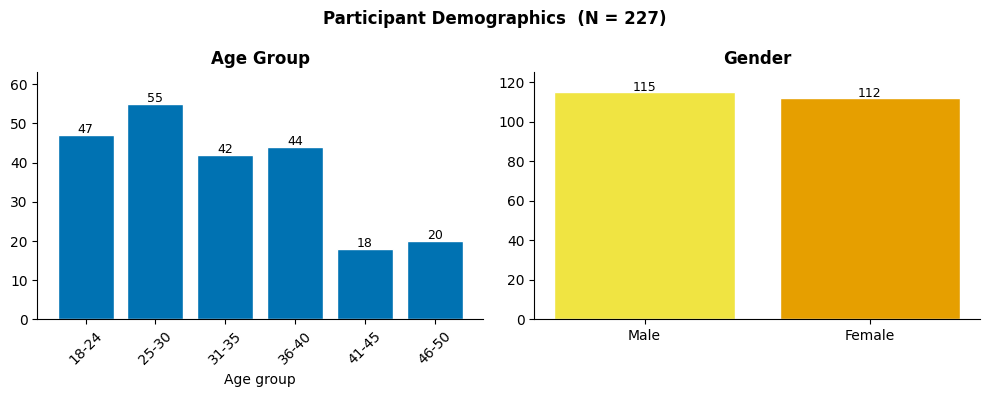

In [3]:
shortlisted_uids = [uid for uids in activity_groups.values() for uid in uids]
participants = (catalog[catalog["sequence_uid"].isin(shortlisted_uids)]
                .drop_duplicates("fake_name")
                .reset_index(drop=True))
n = len(participants)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Age group
age_order = ["18-24", "25-30", "31-35", "36-40", "41-45", "46-50"]
age = participants["participant_age_group"].value_counts().reindex(age_order)
axes[0].bar(age.index, age.values, color=PALETTE["blue"], edgecolor="white")
for i, v in enumerate(age.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=9)
axes[0].set_xlabel("Age group")
axes[0].set_title("Age Group", fontweight="bold")
axes[0].set_ylim(0, age.max() + 8)
axes[0].tick_params(axis="x", labelrotation=45)
axes[0].spines[["top", "right"]].set_visible(False)

# Gender
gen = participants["participant_gender"].value_counts()
axes[1].bar(gen.index, gen.values, color=[PALETTE["yellow"], PALETTE["orange"]], edgecolor="white")
for i, v in enumerate(gen.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=9)
axes[1].set_title("Gender", fontweight="bold")
axes[1].set_ylim(0, gen.max() + 10)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Participant Demographics  (N = {n})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "demographics.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
all_uids = [uid for uids in activity_groups.values() for uid in uids]

session_dfs = {}
skipped = []

print(f"Loading {len(all_uids)} sessions...")
for i, uid in enumerate(all_uids):
    if i % 50 == 0:
        print(f"  {i}/{len(all_uids)}")
    try:
        session_dfs[uid] = pd.read_parquet(SESSIONS_DIR / f"{uid}.parquet")
    except Exception as e:
        skipped.append((uid, str(e)))

print(f"\nDone. Loaded: {len(session_dfs)}  |  Skipped: {len(skipped)}")
for uid, err in skipped:
    print(f"  SKIP {uid} | {err}")


Loading 654 sessions...
  0/654
  50/654
  100/654
  150/654
  200/654
  250/654
  300/654
  350/654
  400/654
  450/654
  500/654
  550/654
  600/654
  650/654

Done. Loaded: 654  |  Skipped: 0


In [5]:
# One mean per session, then mean/SEM across sessions within each activity group.
# avg_yaw_deg = (left_yaw_deg + right_yaw_deg) / 2 per sample (binocular average, not time-averaged).
rows = []
for activity, uids in activity_groups.items():
    for uid in uids:
        if uid not in session_dfs:
            continue
        df = session_dfs[uid]
        rows.append({
            "activity":   activity,
            "uid":        uid,
            "mean_yaw":   df["avg_yaw_deg"].mean(),
            "mean_pitch": df["pitch_deg"].mean(),
        })

participant_means = pd.DataFrame(rows)

centroids = (participant_means
             .groupby("activity")
             .agg(
                 centroid_yaw   = ("mean_yaw",   "mean"),
                 centroid_pitch = ("mean_pitch", "mean"),
                 yaw_se         = ("mean_yaw",   "sem"),
                 pitch_se       = ("mean_pitch", "sem"),
                 n              = ("uid",         "count"),
             )
             .reset_index())

print(centroids.sort_values("centroid_pitch").to_string(index=False))


               activity  centroid_yaw  centroid_pitch   yaw_se  pitch_se   n
        S7-Cooking_Solo     -0.133569      -24.147941 0.219922  0.568582  97
           S11-Laundary     -1.467380      -23.249288 0.382068  1.171910  28
      S7-Cooking_Social     -0.274544      -22.548733 0.290827  0.867343  31
  S10-Housekeeping_Solo     -0.128967      -21.362776 0.272266  0.709500  54
       S8-Having_a_meal     -0.177426      -20.332366 0.347515  0.845097  50
         S12-Game_night     -0.451031      -20.032428 0.233740  0.538426 107
S10-Housekeeping_Social      0.192618      -19.983287 0.517728  1.068297  23
          S2-Where_is_X     -0.139797      -16.759293 0.229890  0.516719  96
          S19-Fresh_air      0.388228      -15.627767 0.275968  0.789201  60
 S3-Welcome_to_my_place     -0.944693      -14.444817 0.399902  0.891505  39
           S13-Charades     -1.084560      -14.329010 0.507147  1.130615  27
      S17-In_the_office     -1.052975      -14.096110 0.682951  1.170461  20

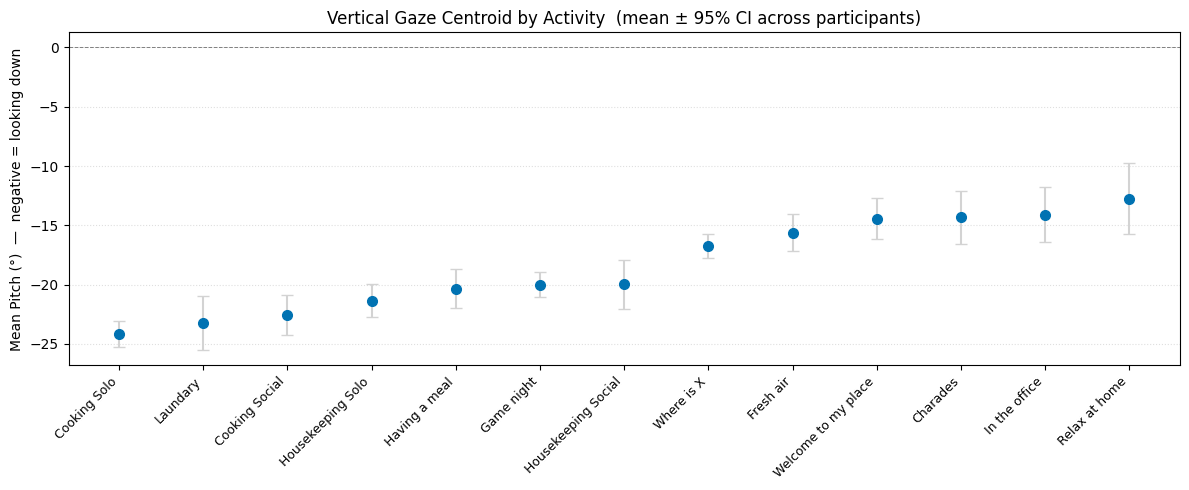

In [6]:
# Rank all activities by mean vertical gaze — the steeper the drop, the more heads-down the activity
plot_centroids = centroids.sort_values("centroid_pitch").reset_index(drop=True)
tick_labels = plot_centroids["activity"].str.split("-", n=1).str[1].str.replace("_", " ")

fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(
    x=range(len(plot_centroids)),
    y=plot_centroids["centroid_pitch"],
    yerr=plot_centroids["pitch_se"] * 1.96,
    fmt="o", color=PALETTE["blue"], ecolor="lightgray",
    elinewidth=1.5, capsize=4, markersize=7
)

ax.set_xticks(range(len(plot_centroids)))
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Mean Pitch (°)  —  negative = looking down")
ax.set_title("Vertical Gaze Centroid by Activity  (mean ± 95% CI across participants)")
ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pitch_centroids.png", dpi=150, bbox_inches="tight")
plt.show()


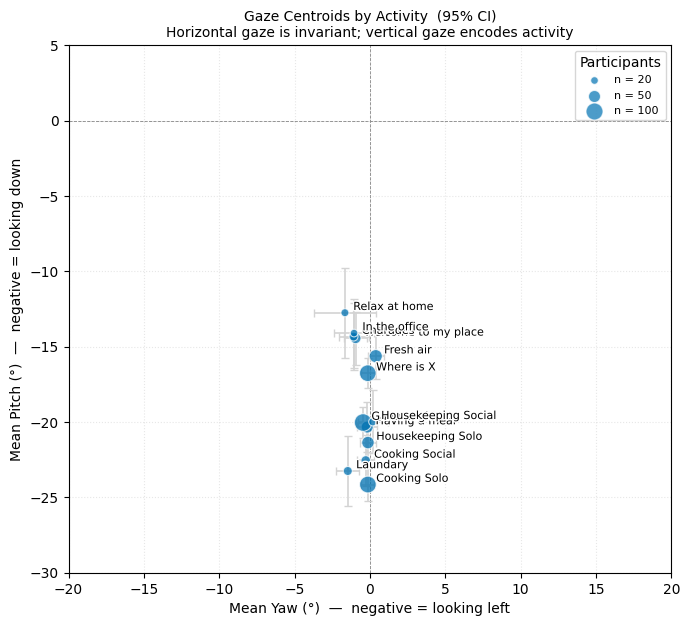

In [7]:
# Yaw vs pitch per activity — horizontal gaze is invariant, vertical gaze encodes activity
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    plot_centroids["centroid_yaw"],
    plot_centroids["centroid_pitch"],
    s=plot_centroids["n"] * 1.5,
    color=PALETTE["blue"], alpha=0.75, zorder=3, edgecolors="white", linewidths=0.8
)

ax.errorbar(
    plot_centroids["centroid_yaw"],
    plot_centroids["centroid_pitch"],
    xerr=plot_centroids["yaw_se"] * 1.96,
    yerr=plot_centroids["pitch_se"] * 1.96,
    fmt="none", ecolor="lightgray", elinewidth=1.2, capsize=3, zorder=2
)

for _, row in plot_centroids.iterrows():
    label = row["activity"].split("-", 1)[1].replace("_", " ")
    ax.annotate(
        label,
        (row["centroid_yaw"], row["centroid_pitch"]),
        textcoords="offset points", xytext=(6, 2),
        fontsize=8,
        path_effects=[pe.withStroke(linewidth=2, foreground="white")]
    )

ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", zorder=1)
ax.axvline(0, color="gray", linewidth=0.6, linestyle="--", zorder=1)
ax.set_xlim(-20, 20)
ax.set_ylim(-30, 5)
ax.set_aspect("equal")
ax.set_xlabel("Mean Yaw (°)  —  negative = looking left", fontsize=10)
ax.set_ylabel("Mean Pitch (°)  —  negative = looking down", fontsize=10)
ax.set_title("Gaze Centroids by Activity  (95% CI)\nHorizontal gaze is invariant; vertical gaze encodes activity", fontsize=10)
ax.grid(linestyle=":", alpha=0.3)

for n_val in [20, 50, 100]:
    ax.scatter([], [], s=n_val * 1.5, color=PALETTE["blue"], alpha=0.7,
               label=f"n = {n_val}", edgecolors="white", linewidths=0.8)
ax.legend(title="Participants", framealpha=0.8, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "centroids_2d.png", dpi=150, bbox_inches="tight")
plt.show()


zmax clipped to 99th percentile: 2.18e-03  (raw max: 1.22e-02)


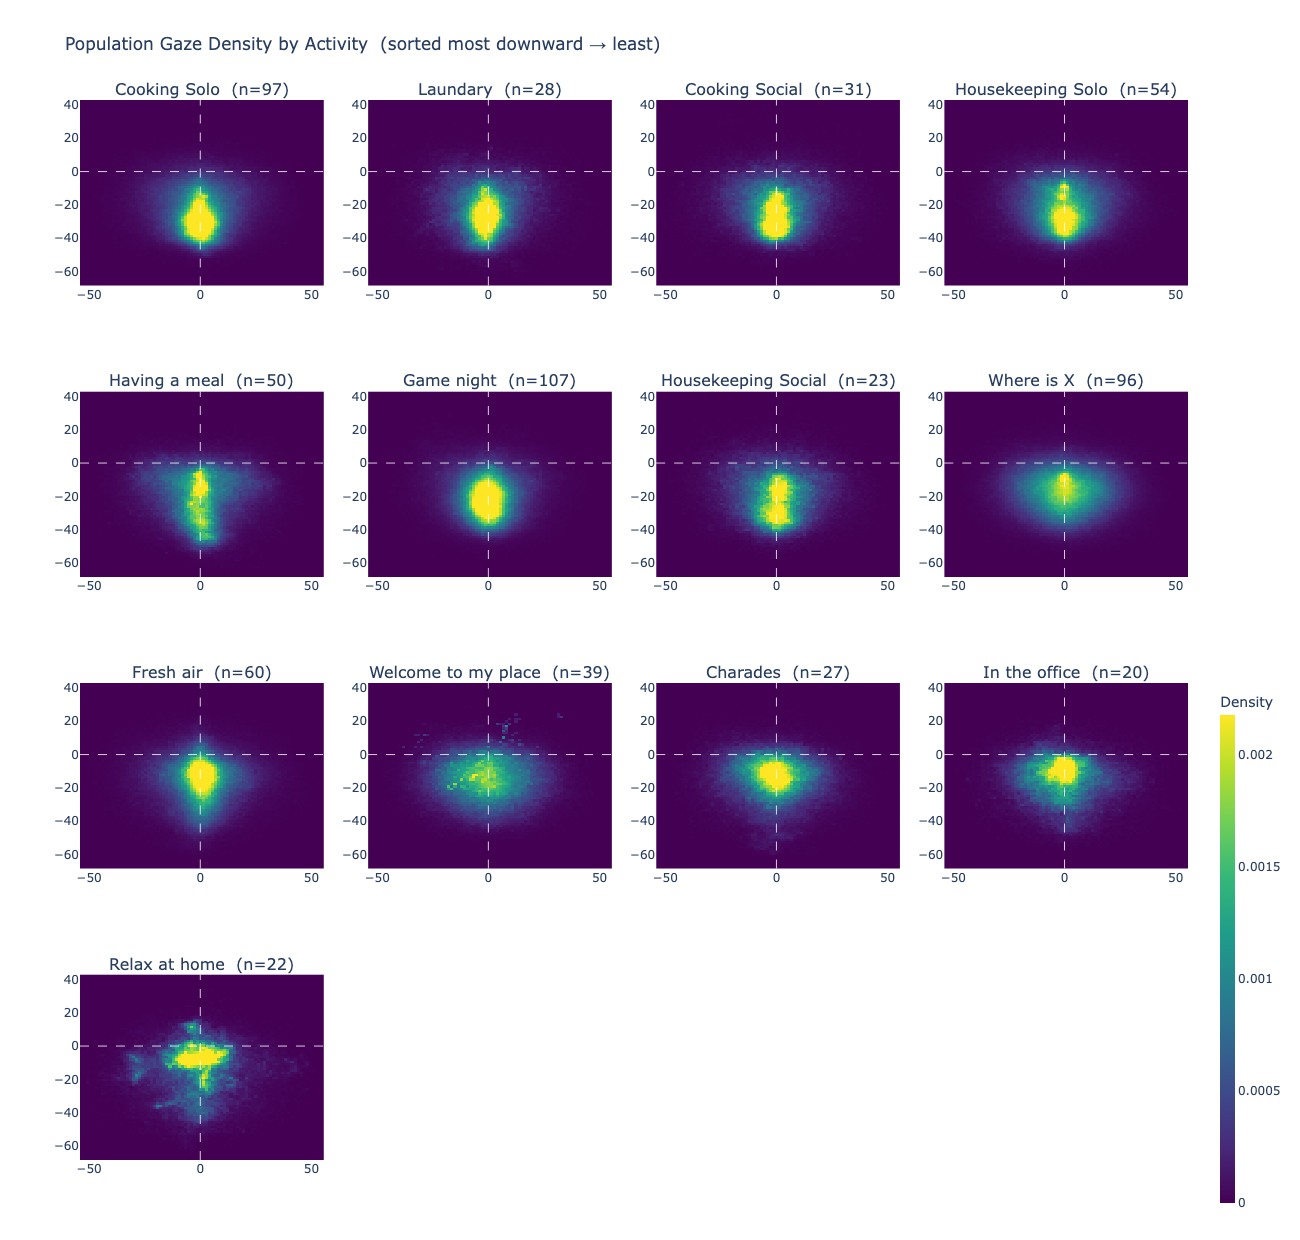

In [8]:
# Per-activity population gaze density: average of per-session normalized 2D histograms on shared bins, sorted by pitch
BINS   = 80
N_COLS = 4

activity_order = centroids.sort_values("centroid_pitch")["activity"].tolist()

all_dfs = [session_dfs[uid] for uids in activity_groups.values() for uid in uids if uid in session_dfs]
x_all   = pd.concat([df["avg_yaw_deg"].dropna() for df in all_dfs])
y_all   = pd.concat([df["pitch_deg"].dropna()   for df in all_dfs])
x_edges = np.linspace(x_all.min(), x_all.max(), BINS + 1)
y_edges = np.linspace(y_all.min(), y_all.max(), BINS + 1)
x_ctr   = (x_edges[:-1] + x_edges[1:]) / 2
y_ctr   = (y_edges[:-1] + y_edges[1:]) / 2

z_maps = {}
for activity, uids in activity_groups.items():
    maps = []
    for uid in uids:
        if uid not in session_dfs:
            continue
        df = session_dfs[uid]
        h, _, _ = np.histogram2d(df["avg_yaw_deg"].dropna(), df["pitch_deg"].dropna(),
                                 bins=[x_edges, y_edges])
        if h.sum() > 0:
            maps.append(h / h.sum())
    z_maps[activity] = np.mean(maps, axis=0).T if maps else np.zeros((BINS, BINS))

# # A few pixels at the gaze hotspot get very high density values and would dominate the colorscale,
# making everything else look dark. Clipping zmax to the 99th percentile stretches the colors
# across the actual spread of the data so the full gaze pattern is visible.
all_density_values = np.concatenate([z.ravel() for z in z_maps.values()])
zmin = 0
zmax = np.percentile(all_density_values, 99)
print(f"zmax clipped to 99th percentile: {zmax:.2e}  (raw max: {all_density_values.max():.2e})")

n_rows = math.ceil(len(activity_order) / N_COLS)
PANEL_SIZE = 280

subplot_titles = [
    f"{act.split('-', 1)[1].replace('_', ' ')}  (n={len([u for u in activity_groups[act] if u in session_dfs])})"
    for act in activity_order
]

fig = make_subplots(
    rows=n_rows, cols=N_COLS,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.04,
    vertical_spacing=0.10,
)

for idx, act in enumerate(activity_order):
    row = idx // N_COLS + 1
    col = idx % N_COLS + 1
    is_last = idx == len(activity_order) - 1
    fig.add_trace(
        go.Heatmap(
            x=x_ctr, y=y_ctr, z=z_maps[act],
            colorscale="viridis",
            zmin=zmin, zmax=zmax,
            showscale=is_last,
            colorbar=dict(title="Density", thickness=15, len=0.5, y=0.2) if is_last else None,
        ),
        row=row, col=col,
    )
    fig.add_hline(y=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)
    fig.add_vline(x=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)

fig.update_layout(
    title_text="Population Gaze Density by Activity  (sorted most downward → least)",
    width=PANEL_SIZE * N_COLS + 180,
    height=PANEL_SIZE * n_rows + 120,
    autosize=False,
)
fig.show()
fig.write_image(FIGURES_DIR / "density_grid.png")


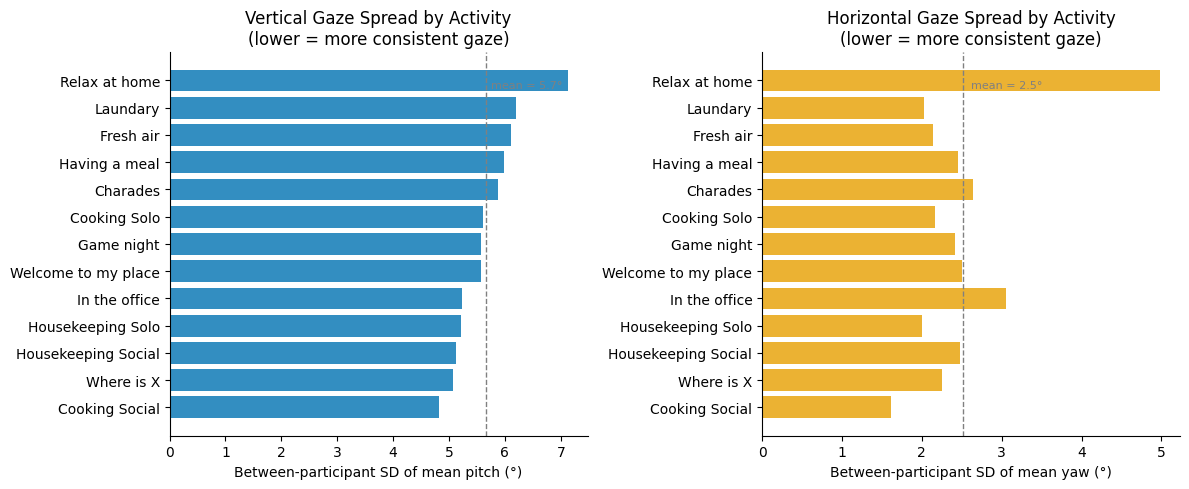

In [9]:
# How consistent is gaze within each activity? Lower SD = participants agree on where to look.
spread = (participant_means
          .groupby("activity")
          .agg(
              pitch_sd = ("mean_pitch", "std"),
              yaw_sd   = ("mean_yaw",   "std"),
              n        = ("uid",         "count"),
          )
          .reset_index()
          .sort_values("pitch_sd")
          .reset_index(drop=True))

labels_spread = spread["activity"].str.split("-", n=1).str[1].str.replace("_", " ")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.barh(labels_spread, spread["pitch_sd"], color=PALETTE["blue"], alpha=0.8)
ax.axvline(spread["pitch_sd"].mean(), color="gray", linestyle="--", linewidth=1)
ax.text(spread["pitch_sd"].mean() + 0.1, len(spread) - 1,
        f"mean = {spread['pitch_sd'].mean():.1f}°", fontsize=8, va="top", color="gray")
ax.set_xlabel("Between-participant SD of mean pitch (°)")
ax.set_title("Vertical Gaze Spread by Activity\n(lower = more consistent gaze)")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.barh(labels_spread, spread["yaw_sd"], color=PALETTE["orange"], alpha=0.8)
ax.axvline(spread["yaw_sd"].mean(), color="gray", linestyle="--", linewidth=1)
ax.text(spread["yaw_sd"].mean() + 0.1, len(spread) - 1,
        f"mean = {spread['yaw_sd'].mean():.1f}°", fontsize=8, va="top", color="gray")
ax.set_xlabel("Between-participant SD of mean yaw (°)")
ax.set_title("Horizontal Gaze Spread by Activity\n(lower = more consistent gaze)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gaze_spread.png", dpi=150, bbox_inches="tight")
plt.show()


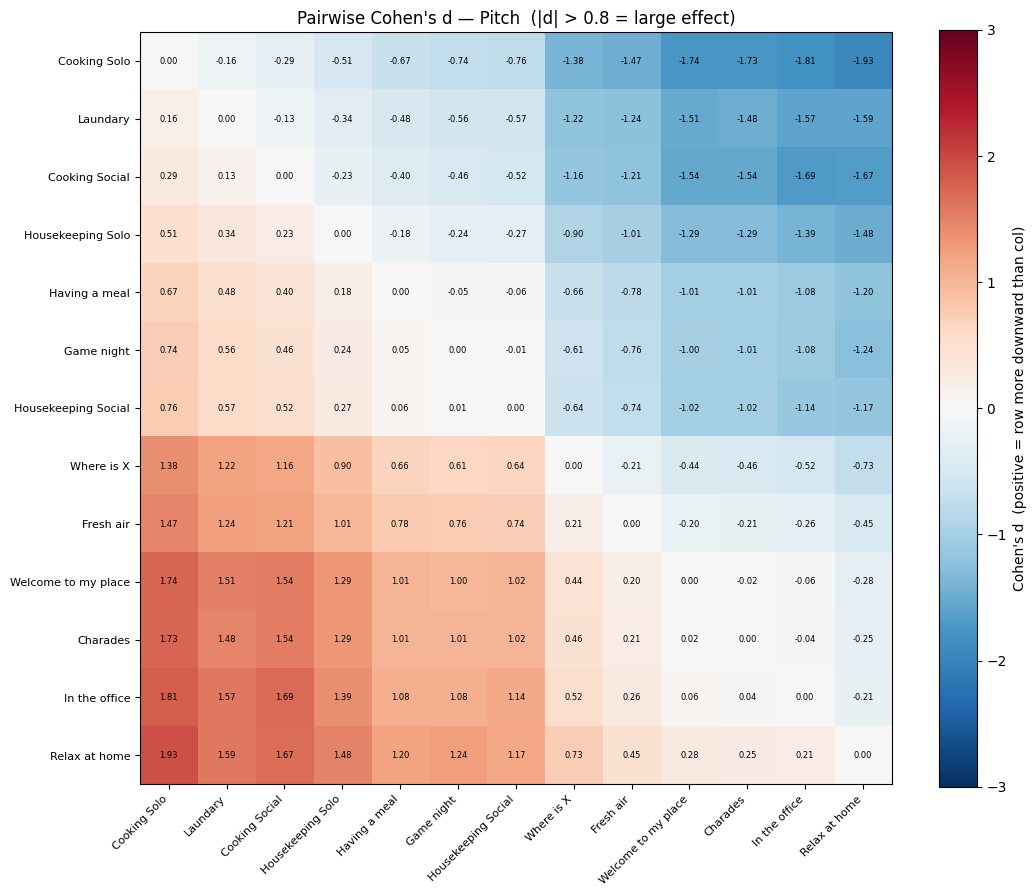

In [10]:
# Pairwise effect sizes between activities — confirms pitch differences are not just statistically significant but practically meaningful
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd

pitch_order    = centroids.sort_values("centroid_pitch")["activity"].tolist()
pitch_labels   = [a.split("-", 1)[1].replace("_", " ") for a in pitch_order]

d_matrix = pd.DataFrame(np.nan, index=pitch_labels, columns=pitch_labels)
for lbl in pitch_labels:
    d_matrix.loc[lbl, lbl] = 0.0

for a1, a2 in combinations(pitch_order, 2):
    vals_a = participant_means[participant_means["activity"] == a1]["mean_pitch"].values
    vals_b = participant_means[participant_means["activity"] == a2]["mean_pitch"].values
    d      = cohens_d(vals_a, vals_b)
    l1     = a1.split("-", 1)[1].replace("_", " ")
    l2     = a2.split("-", 1)[1].replace("_", " ")
    d_matrix.loc[l1, l2] = d
    d_matrix.loc[l2, l1] = -d

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(d_matrix.values.astype(float), cmap="RdBu_r", vmin=-3, vmax=3)
plt.colorbar(im, ax=ax, label="Cohen's d  (positive = row more downward than col)")

ax.set_xticks(range(len(pitch_labels)))
ax.set_yticks(range(len(pitch_labels)))
ax.set_xticklabels(pitch_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(pitch_labels, fontsize=8)

for i in range(len(pitch_labels)):
    for j in range(len(pitch_labels)):
        val = d_matrix.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color="black" if abs(val) < 2 else "white")

ax.set_title("Pairwise Cohen's d — Pitch  (|d| > 0.8 = large effect)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cohens_d.png", dpi=150, bbox_inches="tight")
plt.show()
